C:\Users\igork\AppData\Local\Temp\ipykernel_19244\458938537.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  rho = torch.tensor(np.array(rho0, dtype=complex))


data_times dtype: float64
data_times shape: (11,)
data_values dtype: complex128
data_values shape: (11, 1, 4, 4)
collocation_points_times dtype: float64
collocation_points_times shape: (1000,)
dt 0.10000000000000002
Epoch [0/10000], Data Loss: 0.04312, Physics Loss: 0.00006
Epoch [100/10000], Data Loss: 0.01460, Physics Loss: 0.00007
Epoch [200/10000], Data Loss: 0.00760, Physics Loss: 0.00005
Epoch [300/10000], Data Loss: 0.00134, Physics Loss: 0.00004
Epoch [400/10000], Data Loss: 0.00050, Physics Loss: 0.00004
Epoch [500/10000], Data Loss: 0.00041, Physics Loss: 0.00003
Epoch [600/10000], Data Loss: 0.00038, Physics Loss: 0.00002
Epoch [700/10000], Data Loss: 0.00037, Physics Loss: 0.00001
Epoch [800/10000], Data Loss: 0.00036, Physics Loss: 0.00001
Epoch [900/10000], Data Loss: 0.00036, Physics Loss: 0.00001
Epoch [1000/10000], Data Loss: 0.00036, Physics Loss: 0.00000
Epoch [1100/10000], Data Loss: 0.00036, Physics Loss: 0.00000
Epoch [1200/10000], Data Loss: 0.00036, Physics Loss

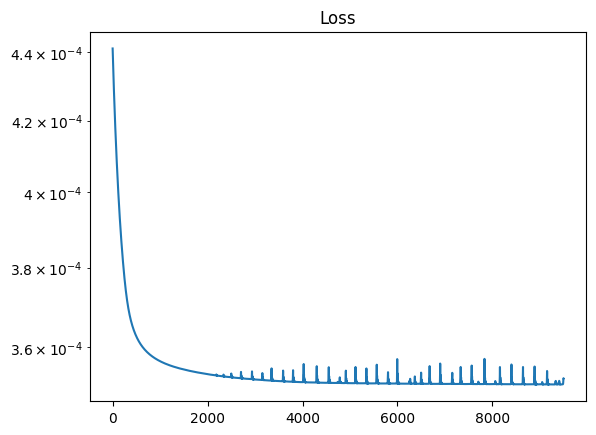

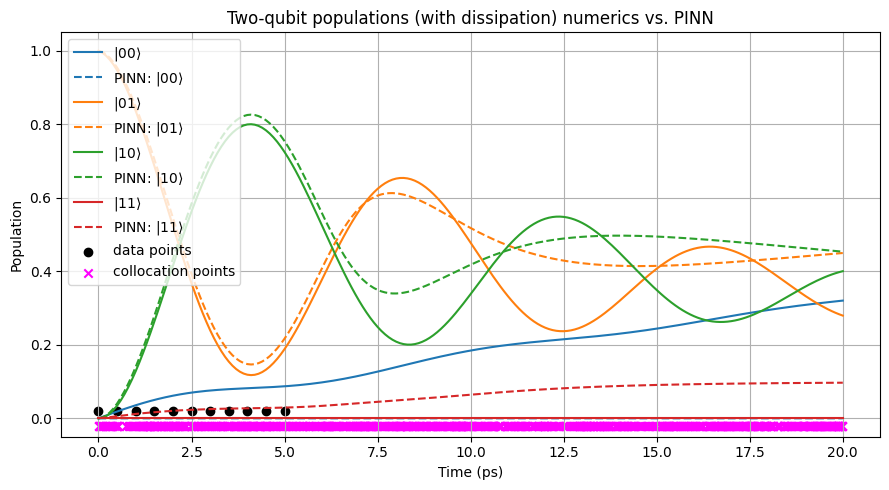

In [4]:
#This code is from repository: #https://github.com/jarek-pawlowski/LindbladianLearning/blob/main/pinn_lindblad.py and does not belong to me 
import numpy as np
from scipy.integrate import solve_ivp
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

# Atomic units
Eh = 27211.  # Eh = 27211 meV
Th = 2.42e-5 # Th = 2.42 x 10^-5 ps

# Dwie funkcje pożyczone od Ziemka

def plot_signals(signals, t_axis = None, labels=None, points=None, pointlabels=None):
    fig, ax = plt.subplots()
    for s, sig in enumerate(signals):
        if t_axis is None:
            t_axis = np.linspace(0.,1., num=len(sig), endpoint=True)
        ax.plot(t_axis, sig, label=labels[s])
    if points is not None:
        for p, pts in enumerate(points):
            ax.scatter(pts[0], pts[1], marker='x', label=pointlabels[p])
    if labels is not None or pointlabels is not None: ax.legend()
    plt.show()

def FixRho(rho):
    # Handle both 2D (N,N) and 3D batched (B,N,N) inputs
    squeeze = rho.ndim == 2
    if squeeze:
        rho = rho.unsqueeze(0)

    # 1. Force Hermitian (more aggressively)
    rho_dag = rho.conj().transpose(1, 2)
    rho = (rho + rho_dag) / 2
    # Add tiny regularization to diagonal to help convergence
    eps = 1e-10
    eye = torch.eye(rho.shape[-1], dtype=rho.dtype, device=rho.device)
    rho = rho + eps * eye.unsqueeze(0)

    # 2. Batched eigen-decomposition
    eigvals, eigvecs = torch.linalg.eigh(rho)

    # 3. Clip negative eigenvalues
    eigvals = torch.clamp(eigvals, min=0)

    # 4. Reconstruct:  V @ diag(λ) @ V†
    rho_fixed = eigvecs @ torch.diag_embed(eigvals.to(eigvecs.dtype)) @ eigvecs.conj().transpose(1, 2)
    # 5. Normalize trace

    trace = rho_fixed.diagonal(dim1=1, dim2=2).sum(dim=1)
    rho_fixed = rho_fixed / trace[:, None, None]

    return rho_fixed.squeeze(0) if squeeze else rho_fixed


"""LINDBLAD SOLVER FOR ARBITRARY NUMBER OF QUBITS"""
class Lindblad_solver:
    """
    Solves the Lindblad master equation for the density matrix ρ:

        dρ/dt = -i[H, ρ] + Σ_k γ_k D[L_k](ρ)

    where D[L](ρ) = L ρ L† - ½ {L†L, ρ}  (dissipator)
    """

    def __init__(self, H, L_ops, gammas, dt):
        """
        H      : Hamiltonian (NxN complex array)
        L_ops  : list of jump operators [L_k], each (NxN)
        gammas : list of decay rates [g_k], one per jump operator
        dt     : time step
        """
        self.H      = torch.tensor(np.array(H, dtype=np.complex64))  # complex64, not complex128
        self.L_ops  = [torch.tensor(np.array(L, dtype=np.complex64)) for L in L_ops]
        self.gammas = list(gammas)
        self.dt     = dt
        self.LdagL  = [L.conj().mT @ L for L in self.L_ops]

    def lindblad_rhs(self, rho):
        H = self.H.to(device=rho.device, dtype=rho.dtype)
        drho = -1j * (H @ rho - rho @ H)

        for gamma, Lk, LdLk in zip(self.gammas, self.L_ops, self.LdagL):
            Lk = Lk.to(device=rho.device, dtype=rho.dtype)
            LdLk = LdLk.to(device=rho.device, dtype=rho.dtype)
            drho += gamma * (Lk @ rho @ Lk.conj().mT - 0.5 * (LdLk @ rho + rho @ LdLk))
        return drho

    def _renormalize(self, rho):
        """Enforce Tr(ρ) = 1 after each step to suppress floating-point drift."""
        return rho / np.trace(rho)

    # RK4 step

    def step(self, rho):
        """
        Advance ρ by one time step using classical RK4.
        Returns rho_{n+1}.
        """
        dt = self.dt
        L  = self.lindblad_rhs

        k1 = L(rho)
        k2 = L(rho + 0.5 * dt * k1)
        k3 = L(rho + 0.5 * dt * k2)
        k4 = L(rho +       dt * k3)

        rho_next = rho + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        return FixRho(rho_next)

    # Full trajectory

    def run_simulation(self, rho0, n_steps=1000):
        """
        Propagate from rho0 for n_steps time steps.
        Returns array of shape (n_steps+1, N, N).
        """
        rho = torch.tensor(np.array(rho0, dtype=complex))
        rhos = [rho.clone()]

        times = [0]

        for i in range(n_steps):
            rho = self.step(rho)
            rhos.append(rho.clone())
            times.append((i + 1) * dt)
            #print(np.amin(np.linalg.eigvals(rho.cpu().numpy())))

        return [np.array(times), np.array(rhos)]

    def populations(rhos):
        """Extract diagonal populations from a trajectory array."""
        return np.real(np.einsum('tii->ti', rhos))   # shape (T, N)


"""NUMERICAL SOLUTIONS"""

# 2 qubit - dissipation

J = .5/Eh       # (meV)
dt = .1/Th      # (ps)
#dt = .02/Th      # (ps)
n_steps = 200

H = np.array([
    [1,  0,  0, 0],
    [0, -1,  2, 0],
    [0,  2, -1, 0],
    [0,  0,  0, 1]
], dtype=complex)*J/4
I2 = np.eye(2, dtype=complex)
L1 = np.array([[0, 1],
               [0, 0]], dtype=complex)
L2 = np.array([[1,  0],
               [0, -1]], dtype=complex)
L1 = np.kron(I2, L1)
L2 = np.kron(L2, I2)
L = [L1, L2]

gamma_relax = 0.05 * J   # amplitude damping  (T1-type, relaxation to ground state)
gamma_deph  = 0.1 * J   # dephasing          (T2-type, pure dephasing)
gammas = [gamma_relax, gamma_deph]

psi0 = np.array([0, 1, 0, 0], dtype=complex)
psi0 /= np.linalg.norm(psi0)
psi0 = torch.tensor(psi0, dtype=torch.complex64)
rho0 = torch.outer(psi0, psi0.conj()).unsqueeze(0)

solver_3 = Lindblad_solver(H, L_ops=L, gammas=gammas, dt=dt)
[times_3, rhos_3]  = solver_3.run_simulation(rho0, n_steps=n_steps)
times_3 *= Th  # convert to ps

# Plotting
rhos_np = np.array(rhos_3)  # shape: (n_steps+1, 4, 4) or (n_steps+1, 1, 4, 4)

# Squeeze batch dim if present
if rhos_np.ndim == 4:
    rhos_np = rhos_np.squeeze(1)

pop_00 = rhos_np[:, 0, 0].real
pop_01 = rhos_np[:, 1, 1].real
pop_10 = rhos_np[:, 2, 2].real
pop_11 = rhos_np[:, 3, 3].real


# define NN estimators
def build_mlp(layer_sizes=[1,256,128,64,32,16], regularization=None, activation='tanh', output='linear', dropout_rate=0.2):

    layers = []
    for i in range(len(layer_sizes) - 2):
        linear_layer = nn.Linear(layer_sizes[i], layer_sizes[i+1])

        # assign most suitable initialization for activation functions
        if activation == 'relu':
            nn.init.kaiming_normal_(linear_layer.weight,
                                    mode='fan_in', nonlinearity='relu')
        elif activation == 'tanh':
            nn.init.xavier_uniform_(linear_layer.weight)
        else:
            nn.init.kaiming_normal_(linear_layer.weight,
                                    mode='fan_in', nonlinearity='leaky_relu')
        # Add the initialized linear layer to the model
        layers.append(linear_layer)

        if regularization == 'batch_normalization':
            layers.append(nn.BatchNorm1d(layer_sizes[i+1]))
        elif regularization == 'dropout':
            layers.append(nn.Dropout(p=dropout_rate))

        if activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'tanh':
            layers.append(nn.Tanh())
        else:
            layers.append(nn.LeakyReLU())

    linear_layer = nn.Linear(layer_sizes[-2], layer_sizes[-1])
    nn.init.xavier_uniform_(linear_layer.weight)
    layers.append(linear_layer)
    if output == 'lrelu':
        layers.append(nn.LeakyReLU())
    elif output == 'tanh':
        layers.append(nn.Tanh())
    #layers.append(nn.Softmax(dim=1))
    model = nn.Sequential(*layers)
    return model


class ResBlock(nn.Module):
    def __init__(self, width, activation=nn.SiLU):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(width, width),
            activation(),
            nn.Linear(width, width)
        )
        self.act = activation()

    def forward(self, x):
        return self.act(x + self.net(x))
    

class MLP_head(nn.Module):
    def __init__(self, width=8, depth=4):
        super().__init__()
        self.blocks = nn.Sequential(
            nn.Linear(1, width),
            nn.ReLU(),
            *[ResBlock(width, nn.ReLU) for _ in range(depth)],
            nn.Linear(width, 2)
        ) 

    def forward(self, x):
        x = self.blocks(x)
        return x[..., 0].to(torch.cfloat) + 1j * x[..., 1]


class MLP_PINN(nn.Module):
    def __init__(self, width=8, depth=4):
        super().__init__()
    
        self.mlps = nn.ModuleList([
            MLP_head(width, depth) for _ in range(16)
        ])

    def forward(self, x):
        return torch.stack([mlp(x) for mlp in self.mlps]).T.reshape(-1, 4, 4)


class LindbladPINN(nn.Module):
    """
    Predicts rho(t) for a 4x4 density matrix using
        rho = L L^\dagger / Tr(L L^\dagger)

    Output dimension: 16 real parameters:
    - 4 real diagonal entries of L
    - 6 complex lower-triangular entries = 12 real numbers
    """
    def __init__(self, width=256, depth=6):
        super().__init__()

        self.input = nn.Sequential(
            nn.Linear(1, width),
            nn.SiLU()
        )

        self.blocks = nn.Sequential(
            *[ResBlock(width, nn.SiLU) for _ in range(depth)]
        )

        self.output = nn.Linear(width, 16)

        #self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def params_to_rho(self, p):
        batch = p.shape[0]
        L = torch.zeros(batch, 4, 4, dtype=torch.cfloat, device=p.device)

        # Positive real diagonal
        diag = F.softplus(p[:, 0:4]) + 1e-6
        for i in range(4):
            L[:, i, i] = diag[:, i].to(torch.cfloat)

        # Complex lower-triangular entries (L in Cholesky decomposition)
        idx = 4
        for i in range(1, 4):
            for j in range(i):
                real = p[:, idx]
                imag = p[:, idx + 1]
                L[:, i, j] = torch.complex(real, imag)
                idx += 2

        rho = L @ L.conj().transpose(-1, -2)
        tr = torch.einsum('bii->b', rho)
        rho = rho / tr[:, None, None]

        return rho

    def forward(self, t):
        x = self.input(t)
        x = self.blocks(x)
        params = self.output(x)
        return self.params_to_rho(params)
        #return torch.reshape(params, (-1, 4, 4)).to(torch.cfloat)


class NN_solver:

    def __init__(self, predictor, solver, data, collocation_points):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.predictor = predictor.to(self.device)
        self.solver = solver
        self.data_points = torch.from_numpy(data[0]).to(torch.float32).view(-1,1).to(self.device)
        self.data_values = torch.from_numpy(data[1]).to(torch.complex64).squeeze(1).reshape(-1, 4, 4).to(self.device)
        self.collocation_points = torch.from_numpy(collocation_points).to(torch.float32).view(-1,1).requires_grad_(True).to(self.device)
        self.dt = self.solver.dt * Th

    def decode_rho(self, out):
        B = out.shape[0]
        rho = torch.zeros(B, 4, 4, dtype=torch.cfloat, device=out.device)

        rho[:, 0, 0] = out[:, 0]
        rho[:, 1, 1] = out[:, 7]
        rho[:, 2, 2] = out[:, 12]
        rho[:, 3, 3] = out[:, 15]

        # off-diagonals (complex)
        pairs = [(0, 1, 1,  2),
                 (0, 2, 3,  4),
                 (0, 3, 5,  6),
                 (1, 2, 8,  9),
                 (1, 3, 10, 11),
                 (2, 3, 13, 14)]

        for (i, j, ri, ii) in pairs:
            val = out[:, ri] + 1j * out[:, ii]
            rho[:, i, j] = val
            rho[:, j, i] = val.conj()

        # tracenorm
        tr = torch.einsum('bii->b', rho)
        for i in range(rho.shape[-2]):
            rho[:,i,i] /= tr[:]

        return rho

    def f_nn(self, t):  # renamed from f_nn1

    # Compute d(out_i)/dt for each output dimension separately
        '''
        doutdt_cols = []
        for i in range(out.shape[1]):
            grad_i = torch.autograd.grad(
                out[:, i].sum(), t,
                create_graph=True
            )[0]  # shape (B, 1)
            doutdt_cols.append(grad_i)
        doutdt = torch.cat(doutdt_cols, dim=1)  # shape (B, 16)
        '''
    #   rho    = self.decode_rho(self.predictor(t))
    #   rho1   = self.decode_rho(self.predictor(t+self.dt))
    #   drhodt = (rho1-rho)/self.dt
    #   return self.Rho_diff(self.solver.lindblad_rhs(rho), drhodt)
        rho = self.predictor(t)
        rho1 = self.predictor(t + self.dt)
        
        dt = self.dt / Th
        L  = self.solver.lindblad_rhs
        k1 = L(rho)
        k2 = L(rho + 0.5 * dt * k1)
        k3 = L(rho + 0.5 * dt * k2)
        k4 = L(rho +       dt * k3)
        rho_next = rho + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
        return self.Rho_diff(rho_next, rho1)

    def Rho_diff(self, rho1, rho2):
        return F.mse_loss(rho1.real, rho2.real) + F.mse_loss(rho1.imag, rho2.imag)

class Training:

    def __init__(self, nn_solver, no_epochs, lr, physics_loss=False, weight_physics=5.):
        self.nn_solver = nn_solver
        self.no_epochs = no_epochs
        self.physics_loss = physics_loss
        self.weight_physics = weight_physics
        self.optimizer = torch.optim.Adam(self.nn_solver.predictor.parameters(), lr=lr)

    def training_loop(self):
        self.nn_solver.predictor.train()
        
        store_loss = []
        for epoch in range(self.no_epochs):
            self.optimizer.zero_grad()
            #out_pred = self.nn_solver.predictor(self.nn_solver.data_points)
            #rho_pred = self.nn_solver.decode_rho(out_pred)
            rho_pred = self.nn_solver.predictor(self.nn_solver.data_points)
            rho_data = self.nn_solver.data_values
            physicsL = self.nn_solver.f_nn(self.nn_solver.collocation_points)
            dataL = self.nn_solver.Rho_diff(rho_pred, rho_data)
            loss = dataL*1.  #self.nn_solver.collocation_points.shape[0]
            if self.physics_loss:
                loss += physicsL*(self.weight_physics)**2
            loss.backward()
            self.optimizer.step()
            store_loss.append(loss.item())

            if epoch % 100 == 0:
                print(f"Epoch [{epoch}/{self.no_epochs}], Data Loss: {dataL:.5f}, Physics Loss: {physicsL*(self.weight_physics)**2:.5f}")

        #self.plot_prediction()
        plt.plot(store_loss[500:])
        plt.yscale('log')
        plt.title('Loss')
        plt.savefig('pinn_training.png')

# now define PINN solver
#data_indices = np.array([0,5,10,15,20])
data_indices = np.arange(0, 51, 5)
data_times = times_3[data_indices]
data_values = rhos_3[data_indices]
no_collocation_points = 1000
collocation_points_times = np.sort(np.random.uniform(np.min(times_3), np.max(times_3), no_collocation_points))


# solver_nn = NN_solver(predictor=build_mlp(),
#                                solver=solver_3,
#                                data=[data_times, data_values],
#                                collocation_points=collocation_points_times)

#solver_nn = NN_solver(predictor=MLP_PINN(width=64, depth=3),
solver_nn = NN_solver(predictor=LindbladPINN(),
                                solver=solver_3,
                                data=[data_times, data_values],
                                collocation_points=collocation_points_times)

# train NN predictor
train_nn = Training(solver_nn, no_epochs=10000, lr=2.e-5, physics_loss=True, weight_physics=1.)
    
print("data_times dtype:", data_times.dtype)
print("data_times shape:", data_times.shape)
print("data_values dtype:", data_values.dtype)
print("data_values shape:", data_values.shape)
print("collocation_points_times dtype:", collocation_points_times.dtype)
print("collocation_points_times shape:", collocation_points_times.shape)
print("dt", solver_nn.solver.dt*Th)

train_nn.training_loop()

# TEST:
rho_nn = solver_nn.predictor(torch.from_numpy(times_3).to(torch.float32).view(-1,1).to(solver_nn.device)).real.detach().cpu().numpy()
print(rho_nn.shape)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(times_3, pop_00, color='C0', label=r'$|00\rangle$')
ax.plot(times_3, rho_nn[:,0,0], '--', color='C0', label=r'PINN: $|00\rangle$')
ax.plot(times_3, pop_01, color='C1', label=r'$|01\rangle$')
ax.plot(times_3, rho_nn[:,1,1], '--', color='C1', label=r'PINN: $|01\rangle$')
ax.plot(times_3, pop_10, color='C2', label=r'$|10\rangle$')
ax.plot(times_3, rho_nn[:,2,2], '--', color='C2', label=r'PINN: $|10\rangle$')
ax.plot(times_3, pop_11, color='C3', label=r'$|11\rangle$')
ax.plot(times_3, rho_nn[:,3,3], '--', color='C3', label=r'PINN: $|11\rangle$')
ax.scatter(data_times, np.ones_like(data_times)*.02, marker='o', color='black', label='data points')
ax.scatter(collocation_points_times, np.ones_like(collocation_points_times)*-.02, marker='x', color='magenta', label='collocation points')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Population')
ax.set_title('Two-qubit populations (with dissipation) numerics vs. PINN')
ax.legend()
ax.set_ylim(-0.05, 1.05)
ax.grid(True)

plt.tight_layout()
fig.savefig('pinn_test.png')